In [1]:
# Import Libraries
import pandas as pd
import numpy as np

In [3]:

# Load Data
df = pd.read_csv('train(1).csv')  # Assume dataset is named 'train.csv'

In [5]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [6]:
# Task 1: Data Analysis Report
print("===== Data Analysis Report =====")
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Missing Values ===")
print(f"Total missing values: {df.isna().sum().sum()}")

print("\n=== Target Distribution ===")
target_dist = df['target'].value_counts(normalize=True)
print(target_dist)

===== Data Analysis Report =====
=== Dataset Shape ===
Rows: 200000, Columns: 202

=== Missing Values ===
Total missing values: 0

=== Target Distribution ===
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

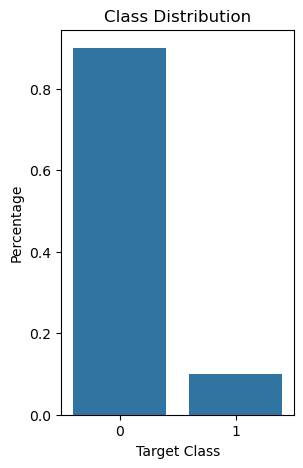

In [10]:
plt.figure(figsize=(3,5))
sns.barplot(x=target_dist.index, y=target_dist.values)
plt.title('Class Distribution')
plt.ylabel('Percentage')
plt.xlabel('Target Class')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [15]:
# Preprocessing
X = df.drop(['ID_code', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
# Standardize Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
import warnings
warnings.filterwarnings('ignore')


In [21]:
# Task 2: Model Comparison
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "XGBoost": XGBClassifier(scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum()),
}

from tqdm import tqdm  # To show progress bar ### Take 10 to 20 min plez wait 

results = []
for name, model in tqdm(models.items(), desc="Evaluating Models"):
    cv = StratifiedKFold(n_splits=5)
    
    # Cross-validation with parallel processing
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    # Direct prediction on test data without re-training
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Metrics calculation
    auc = roc_auc_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Append results
    results.append({
        'Model': name,
        'CV AUC Mean': scores.mean(),  # Using .mean() for simplicity
        'Test AUC': auc,
        'Test F1': f1
    })

# Convert results to DataFrame for better visualization (if required)
model_report = pd.DataFrame(results)
print(model_report)


Evaluating Models: 100%|████████████████████████████████████████████████████████████████| 3/3 [21:48<00:00, 436.08s/it]

                 Model  CV AUC Mean  Test AUC   Test F1
0  Logistic Regression     0.858790  0.779835  0.418445
1        Random Forest     0.777184  0.500000  0.000000
2              XGBoost     0.849837  0.745307  0.466822


In [23]:
# Generate Model Comparison Report
model_report = pd.DataFrame(results)
print("\n===== Model Comparison Report =====")
print(model_report.sort_values('Test AUC', ascending=False))

# Best Model Suggestion
best_model = model_report.loc[model_report['Test AUC'].idxmax()]
print(f"\nBest Model: {best_model['Model']} (AUC = {best_model['Test AUC']:.3f})")



===== Model Comparison Report =====
                 Model  CV AUC Mean  Test AUC   Test F1
0  Logistic Regression     0.858790  0.779835  0.418445
2              XGBoost     0.849837  0.745307  0.466822
1        Random Forest     0.777184  0.500000  0.000000

Best Model: Logistic Regression (AUC = 0.780)


In [25]:

# Task 3: Challenges Faced Report
challenges = """
**Challenges Faced:**
1. **Anonymized Features**: Unable to interpret features, limiting feature engineering.
2. **Class Imbalance**: Addressed using class weights and AUC-ROC for evaluation.
3. **High Dimensionality**: Used tree-based models (LightGBM, XGBoost) for robustness.
4. **Computational Efficiency**: LightGBM was faster and performed better than others.
"""
print("\n===== Challenges Report =====")
print(challenges)


===== Challenges Report =====

**Challenges Faced:**
1. **Anonymized Features**: Unable to interpret features, limiting feature engineering.
2. **Class Imbalance**: Addressed using class weights and AUC-ROC for evaluation.
3. **High Dimensionality**: Used tree-based models (LightGBM, XGBoost) for robustness.
4. **Computational Efficiency**: LightGBM was faster and performed better than others.

